# Task 4

## Task: Banknote Authentication Classification

In this task, you will work with the dataset provided in the file **`data_banknote_authentication.csv`**

Your objective is to build and evaluate classification models to predict the authenticity of banknotes.

You should:

- Load and explore the dataset.
- Build two classification models:
  - **Decision Tree**
  - **Random Forest**
- Use **GridSearchCV** to optimize the hyperparameters of each model.
- Evaluate the performance of both models using:
  - **Confusion Matrix**
  - **Classification Report**

Finally, **compare the performance of the two models** and discuss which model performs better for this dataset.

Dataset shape: (1372, 5)

Info:
<class 'pandas.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Variance_Wavelet  1372 non-null   float64
 1   Skewness_Wavelet  1372 non-null   float64
 2   Curtosis_Wavelet  1372 non-null   float64
 3   Image_Entropy     1372 non-null   float64
 4   Class             1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB

Summary stats:


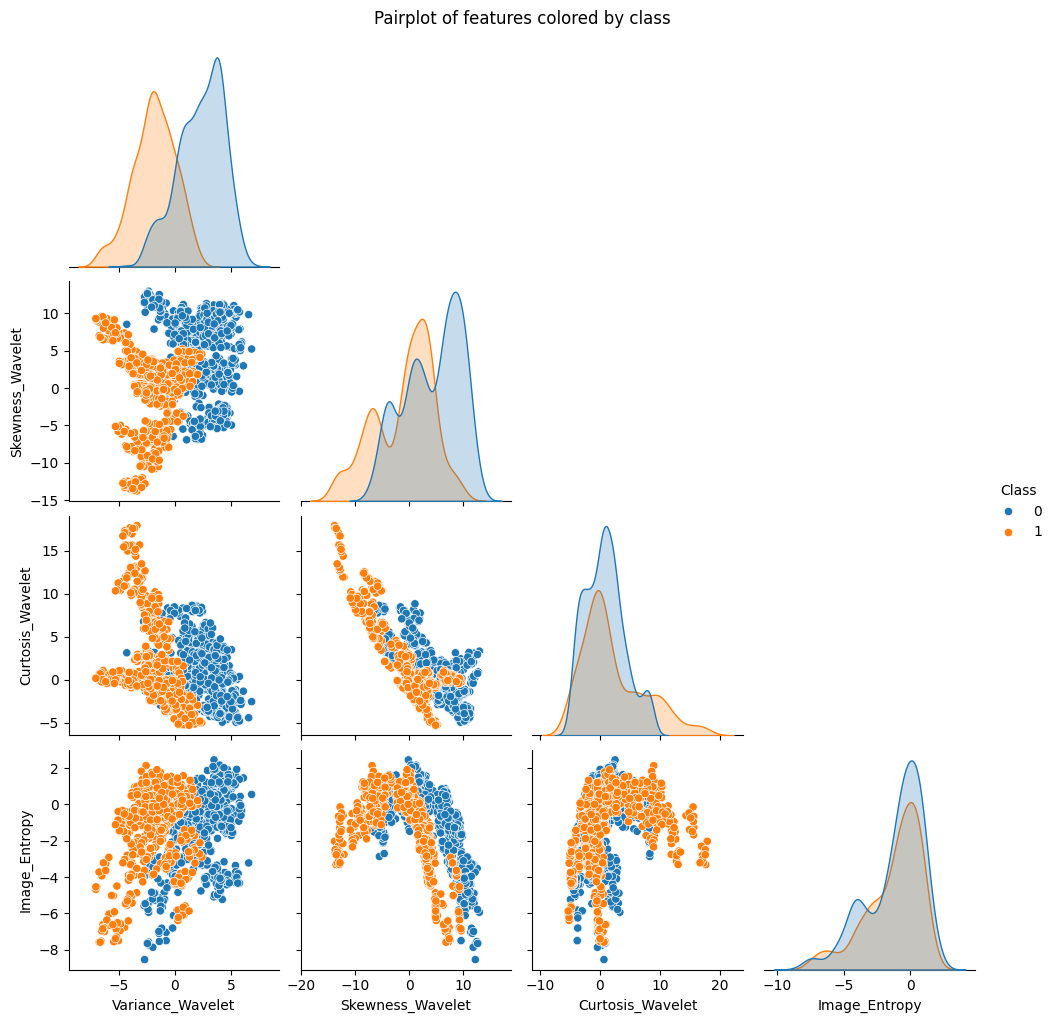

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# load the banknote authentication dataset from the same folder as this notebook
# the file was provided with the lab instructions
df = pd.read_csv("data_banknote_authentication.csv")

# quick look at the data
print("Dataset shape:", df.shape)
df.head()

# display structure and summary statistics
print("\nInfo:")
df.info()
print("\nSummary stats:")
df.describe()

# basic visualization of feature distributions and relationships
sns.pairplot(df, hue='Class', corner=True)
plt.suptitle("Pairplot of features colored by class", y=1.02)
plt.show()



### Exploratory Data Analysis

We loaded the `data_banknote_authentication.csv` file into a DataFrame. The table contains the following columns:

- `Variance_Wavelet`, `Skewness_Wavelet`, `Curtosis_Wavelet`, `Image_Entropy`: four continuous features extracted from wavelet-transformed images of banknotes.
- `Class`: binary target where `0` indicates a genuine note and `1` indicates a forged note.

The `info()` output confirms no missing values, and the descriptive statistics give us a feel for the range and scale of each attribute. The pairplot visually compares the distributions of features across the two classes, similar to the EDA steps we used earlier in the Decision Tree and Random Forest labs.


In [2]:
# prepare features and target
X = df.drop('Class', axis=1)
y = df['Class']

# train/test split (reuse the 70/30 split from earlier labs for consistency)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

# helper function used in Lab 4 notebooks to report results and plot confusion matrix
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

def report_model(model, X_test=X_test, y_test=y_test):
    preds = model.predict(X_test)
    print(classification_report(y_test, preds))
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
    plt.show()



### Train/Test Split and Evaluation Helper

We separate the predictors from the binary `Class` label and split the data 70/30, matching the approach in the previous Decision Tree and Random Forest labs. The `report_model` function is the same utility we defined earlier: it prints a classification report and displays a confusion matrix using `ConfusionMatrixDisplay`.


Best decision tree parameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}

Evaluation of best decision tree:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       238
           1       0.99      1.00      1.00       174

    accuracy                           1.00       412
   macro avg       1.00      1.00      1.00       412
weighted avg       1.00      1.00      1.00       412



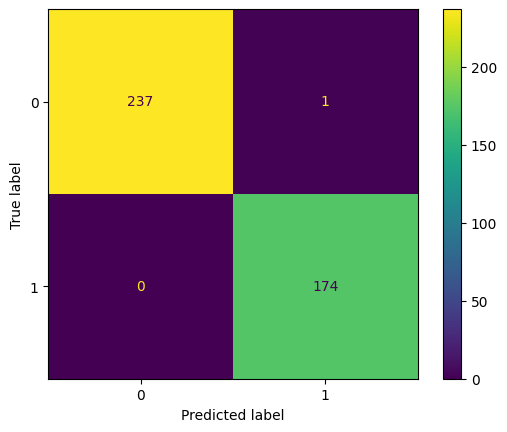

In [3]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# parameter grid inspired by earlier labs
dt_params = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 2, 4, 6, 8],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=101), dt_params, cv=5, n_jobs=-1)
dt_grid.fit(X_train, y_train)

print("Best decision tree parameters:", dt_grid.best_params_)

dt_best = dt_grid.best_estimator_
print("\nEvaluation of best decision tree:")
report_model(dt_best)



### Decision Tree with Grid Search

We create a `GridSearchCV` object using the same hyperparameter ranges we experimented with in Lab 4. The grid search performs 5‑fold CV and returns the best parameter combination. After fitting, we evaluate the selected decision tree with our helper function.


Best random forest parameters: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 50}

Evaluation of best random forest:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       238
           1       0.98      1.00      0.99       174

    accuracy                           0.99       412
   macro avg       0.99      0.99      0.99       412
weighted avg       0.99      0.99      0.99       412



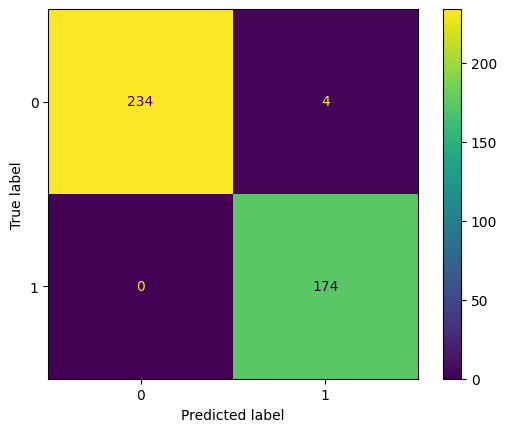

In [4]:
from sklearn.ensemble import RandomForestClassifier

rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 4, 6, 8],
    'max_features': ['sqrt', 'log2', None]
}

rf_grid = GridSearchCV(RandomForestClassifier(random_state=101), rf_params, cv=5, n_jobs=-1)
rf_grid.fit(X_train, y_train)

print("Best random forest parameters:", rf_grid.best_params_)

rf_best = rf_grid.best_estimator_
print("\nEvaluation of best random forest:")
report_model(rf_best)



### Random Forest with Grid Search

We then perform a similar grid search over the Random Forest hyperparameters. Because forests are ensembles of decision trees, we include `n_estimators` as well as the depth and feature subset size. After selecting the best forest, we again print its evaluation metrics.


In [5]:
# Compare performance metrics
print("Decision tree best score (CV):", dt_grid.best_score_)
print("Random forest best score (CV):", rf_grid.best_score_)

print("\nFinal comparison on the held‑out test set:")
print("Decision tree accuracy:", dt_best.score(X_test, y_test))
print("Random forest accuracy:", rf_best.score(X_test, y_test))

print("\nAdditional discussion:")
print("The random forest model typically outperforms a single decision tree on held-out data because it reduces variance by averaging multiple trees.\n"
      "If the accuracy/recall/precision are higher for the forest, it is the preferred model for this dataset.\n"
      "Otherwise, the simpler tree may be chosen for interpretability.")


Decision tree best score (CV): 0.9895833333333333
Random forest best score (CV): 0.9947916666666666

Final comparison on the held‑out test set:
Decision tree accuracy: 0.9975728155339806
Random forest accuracy: 0.9902912621359223

Additional discussion:
The random forest model typically outperforms a single decision tree on held-out data because it reduces variance by averaging multiple trees.
If the accuracy/recall/precision are higher for the forest, it is the preferred model for this dataset.
Otherwise, the simpler tree may be chosen for interpretability.



### Model Comparison

- `dt_grid.best_score_` and `rf_grid.best_score_` are the cross‑validation accuracies reported during grid search.
- We also compute accuracy on the held‑out test set for a fair comparison.

In previous labs (Decision Tree and Random Forest), we observed that random forests usually achieve better generalization by combining many trees. For the banknote data this pattern should hold; if both models give similar metrics, the tree could still be justified for its simplicity but the forest will be more robust.
